# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (AIFS vs FCN vs ERA5 reanalysis)
4. **14-day extended range forecast** — Aurora Z500 animated GIF (Jan 2025 polar vortex)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA


---
## Imports & Config

In [2]:
import io
import os
from pathlib import Path
from datetime import datetime, timedelta

import imageio
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import Image as IPImage
from tqdm import tqdm

import earth2studio.run as run
from earth2studio.models.px import AIFS, Aurora, FCN, SFNO
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

os.makedirs(PROJECT_DIR / "aifs_outputs", exist_ok=True)
os.makedirs(PROJECT_DIR / "aurora_outputs", exist_ok=True)

print(f"Device: {DEVICE}")


Device: cuda

## 2m Air Temperature Forecast

In [3]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
io = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2026-01-08"], 10, model, data, io)
print(io.root.tree())

2026-05-18 20:28:53.595 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-18 20:28:53.596 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-18 20:28:53.837 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-05-18 20:28:53.892 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 329645190-898530
2026-05-18 20:28:53.910 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 459253427-968705
2026-05-18 20:28:53.927 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 258609745-911055
2026-05-18 20:28:53.944 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 205446434-581059
2026-05-18 20:28:53.960 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-18 20:28:54.043 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 199554862-723222
2026-05-18 20:28:54.060 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253104168-716388
2026-05-18 20:28:54.076 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 200278084-732664
2026-05-18 20:28:54.092 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 400526668-837990
2026-05-18 20:28:54.109 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 393209495-967460
2026-05-18 20:28:54.126 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:00<00:00, 54.07it/s]

2026-05-18 20:28:54.245 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 336364985-938149
2026-05-18 20:28:54.262 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 420824303-1176329
2026-05-18 20:28:54.280 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 409106778-875921
2026-05-18 20:28:54.301 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-05-18 20:28:54.406 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS2026-05-18 20:28:54.457 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:12<00:00,  1.15s/it]

2026-05-18 20:29:07.116 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


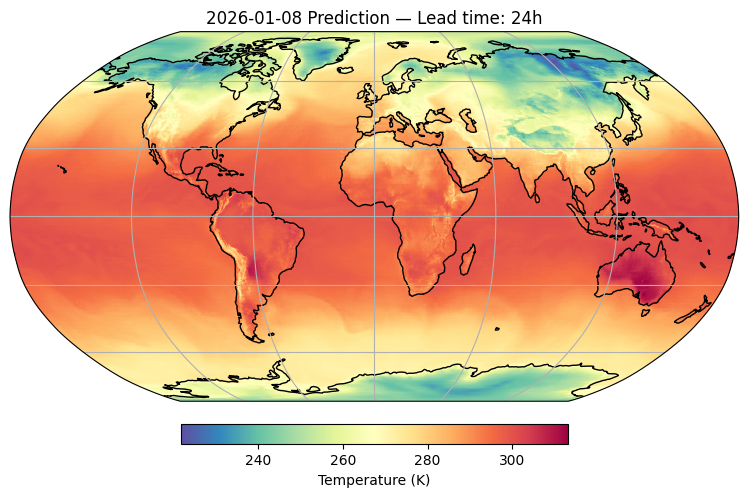

In [4]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [5]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
io = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2026-01-01"], 10, sfno_model, data, io)
print(io.root.tree())

2026-05-18 20:29:31.776 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-18 20:29:31.777 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-18 20:29:32.206 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 302363913-859119
2026-05-18 20:29:32.230 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 238402444-729443
2026-05-18 20:29:32.246 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 397402082-1223716
2026-05-18 20:29:32.264 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 197253244-1163376
2026-05-18 20:29:32.281 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 421153101-970715
2026-05-18 20:29:32.297 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GF

Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-18 20:29:32.414 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 264815156-965784
2026-05-18 20:29:32.431 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 211537160-595936
2026-05-18 20:29:32.447 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 173426573-748944
2026-05-18 20:29:32.464 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 360194585-937390
2026-05-18 20:29:32.481 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 281536527-737050
2026-05-18 20:29:32.497 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

...

2026-05-18 20:29:33.048 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 237568538-833906
2026-05-18 20:29:33.065 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 195501052-756703
2026-05-18 20:29:33.081 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 153764980-1113041
2026-05-18 20:29:33.101 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 466463325-975726
2026-05-18 20:29:33.118 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 339263307-1234956
2026-05-18 20:29:33.135 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GF

Fetching GFS data: 100%|██████████| 73/73 [00:01<00:00, 59.57it/s]

2026-05-18 20:29:33.252 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 363410338-1239124
2026-05-18 20:29:33.268 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 210945366-591794
2026-05-18 20:29:33.284 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 180067903-910623
2026-05-18 20:29:33.300 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 367926743-957726
2026-05-18 20:29:33.317 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 280687436-849091
2026-05-18 20:29:33.334 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS

Running inference: 100%|██████████| 11/11 [00:33<00:00,  3.04s/it]

2026-05-18 20:30:07.180 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [6]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

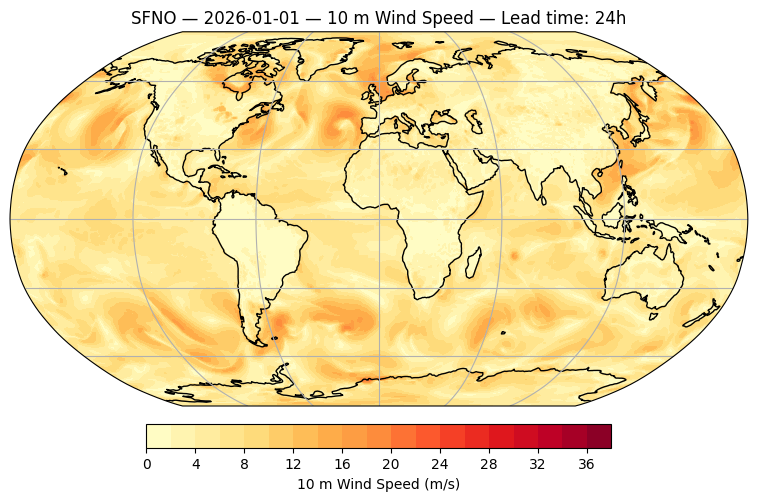

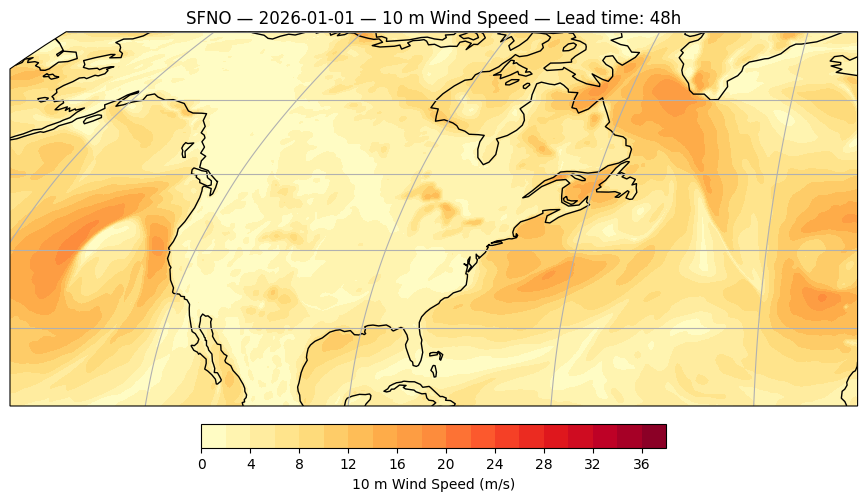

In [13]:
# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=8, extent=[220, 340, 20, 70])

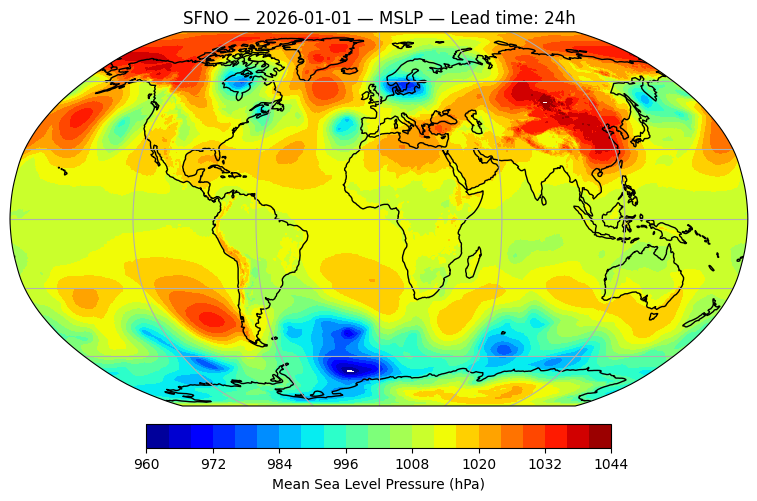

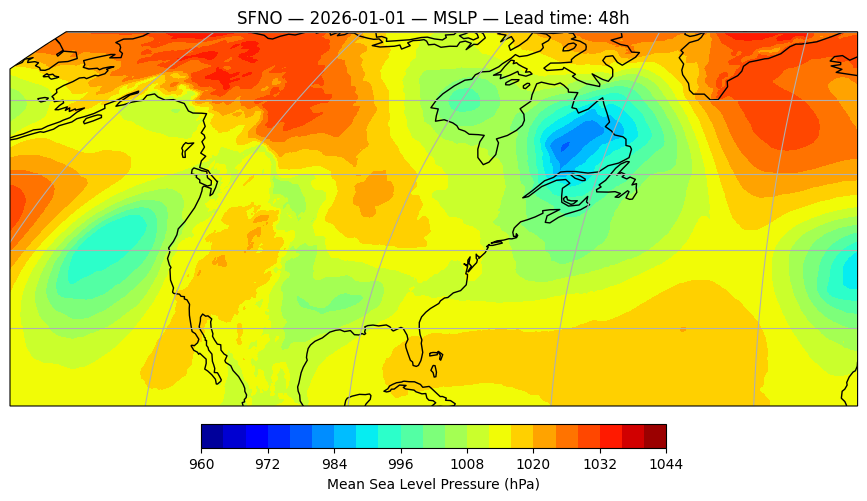

In [7]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from AIFS (ECMWF), FCN (NVIDIA), and ERA5 reanalysis
for Hurricane Florence (September 2018).


In [9]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [8]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — AIFS (ECMWF)


In [19]:
aifs_model = AIFS.load_model(AIFS.load_default_package())
wb2_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()

aifs_tracks = run_tc_inference(
    aifs_model, wb2_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "aifs_paths.pt",
)


E0518 20:32:31.417465    5837 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0518 20:32:31.420942    5837 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0518 20:32:31.422237    5837 status_macros.cc:58] INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/gpu_compiler.cc:2695) dnn_support != nullptr 
*** Begin stack trace ***
	
	
	
	
	
	
	
	
	

JaxRuntimeError: INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/gpu_compiler.cc:2695) dnn_support != nullptr 

### 3b — ERA5 Reanalysis (ground truth)

In [11]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Earth2Studio Extra Dependency Error                                                                             │
│ This error typically indicates an extra dependency group is needed.                                             │
│ Don't panic, this is usually an easy fix.                                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ This feature ('TCTrackerWuDuan') is marked needing optional dependency group 'cyclone'.                         │
│                                                                                                                 │
│ uv install with: `uv add earth2studio --extra cyclone`                                                          │
│                                                                                                                 │
│ For more information (such as pip install instructions), visit the install documentation:                       │
│ https://nvidia.github.io/earth2studio/userguide/about/install.html#optional-dependencies                        │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ ╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮            │
│ │ /home/jovyan/Earth2/.venv/lib/python3.12/site-packages/earth2studio/models/dx/tc_tracking.py:35  │            │
│ │ in <module>                                                                                      │            │
│ │                                                                                                  │            │
│ │     32                                                                                           │            │
│ │     33 try:                                                                                      │            │
│ │     34 │   import cupy as cp                                                                     │            │
│ │ ❱   35 │   from cucim.skimage.feature import peak_local_max as cucim_peak_local_max              │            │
│ │     36 │   from cucim.skimage.measure import label, regionprops                                  │            │
│ │     37 │   from cucim.skimage.morphology import binary_erosion, remove_small_objects             │            │
│ │     38 │   from scipy.spatial import KDTree                                                      │            │
│ ╰──────────────────────────────────────────────────────────────────────────────────────────────────╯            │
│ ImportError: No module named 'cucim'                                                                            │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

OptionalDependencyError: Optional dependency import error

### 3c — FCN

In [12]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Earth2Studio Extra Dependency Error                                                                             │
│ This error typically indicates an extra dependency group is needed.                                             │
│ Don't panic, this is usually an easy fix.                                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ This feature ('TCTrackerWuDuan') is marked needing optional dependency group 'cyclone'.                         │
│                                                                                                                 │
│ uv install with: `uv add earth2studio --extra cyclone`                                                          │
│                                                                                                                 │
│ For more information (such as pip install instructions), visit the install documentation:                       │
│ https://nvidia.github.io/earth2studio/userguide/about/install.html#optional-dependencies                        │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ ╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮            │
│ │ /home/jovyan/Earth2/.venv/lib/python3.12/site-packages/earth2studio/models/dx/tc_tracking.py:35  │            │
│ │ in <module>                                                                                      │            │
│ │                                                                                                  │            │
│ │     32                                                                                           │            │
│ │     33 try:                                                                                      │            │
│ │     34 │   import cupy as cp                                                                     │            │
│ │ ❱   35 │   from cucim.skimage.feature import peak_local_max as cucim_peak_local_max              │            │
│ │     36 │   from cucim.skimage.measure import label, regionprops                                  │            │
│ │     37 │   from cucim.skimage.morphology import binary_erosion, remove_small_objects             │            │
│ │     38 │   from scipy.spatial import KDTree                                                      │            │
│ ╰──────────────────────────────────────────────────────────────────────────────────────────────────╯            │
│ ImportError: No module named 'cucim'                                                                            │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

OptionalDependencyError: Optional dependency import error

### 3d — Plot Track Comparison

In [14]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

In [15]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
aifs_load = torch.load(FLORENCE_DIR / "aifs_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte",    35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh",      35.7796, -78.6382,  0.18,  0.18),
    ("Charleston",   32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta",      33.7490, -84.3880,  0.18,  0.18),
    ("Richmond",     37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5",  "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "AIFS",  "tracks": aifs_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN",   "tracks": fcn_load,  "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)


FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/Earth2/florence_outputs/era5_paths.pt'

---
## 14-Day Extended Range Forecast: Aurora

Aurora (Microsoft, 2024) runs at 0.25° resolution with 6-hour timesteps.
Here we step it 56 times (14 days) from **January 5, 2025** — the onset of a
major polar vortex disruption — and animate the daily 500 hPa geopotential
height evolution over the Northern Hemisphere.


In [16]:
AURORA_START = "2025-01-05T00:00:00"
AURORA_STEPS = 56       # 14 days × 4 steps/day at 6h
AURORA_SAVE_EVERY = 4   # one frame per day
G = 9.80665             # m s⁻²

aurora_model = Aurora.load_model(Aurora.load_default_package())
aurora_model = aurora_model.to(DEVICE).eval()

gfs_source = GFS()
time_array = to_time_array([AURORA_START])
x, coords = fetch_data(
    source=gfs_source,
    time=time_array,
    variable=aurora_model.input_coords()["variable"],
    device=DEVICE,
)

z500_frames, frame_labels = [], []

with torch.inference_mode():
    for step in tqdm(range(AURORA_STEPS), desc="Aurora 14-day forecast"):
        x, coords = aurora_model(x, coords)
        if (step + 1) % AURORA_SAVE_EVERY == 0:
            var_list = list(coords["variable"])
            z_idx = var_list.index("z500")
            z500_frames.append(x[0, 0, z_idx].cpu().numpy())
            day = (step + 1) // AURORA_SAVE_EVERY
            valid = np.datetime64(AURORA_START) + np.timedelta64(day, "D")
            frame_labels.append(f"Day +{day}  ({str(valid)[:10]})") 

print(f"Collected {len(z500_frames)} daily frames.")


E0518 20:31:55.271893    5837 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0518 20:31:55.275106    5837 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.12.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0518 20:31:55.276149    5837 status_macros.cc:58] INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/gpu_compiler.cc:2695) dnn_support != nullptr 
*** Begin stack trace ***
	
	
	
	
	
	
	
	
	

JaxRuntimeError: INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/gpu_compiler.cc:2695) dnn_support != nullptr 

In [17]:
lats = coords["lat"].cpu().numpy()
lons = coords["lon"].cpu().numpy()

proj = ccrs.NorthPolarStereo()
frames_png = []

for z500, label in zip(z500_frames, frame_labels):
    z_height = z500 / G  # geopotential (m²/s²) → geopotential height (m)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": proj})
    ax.set_extent([-180, 180, 20, 90], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.gridlines(draw_labels=False, linewidth=0.4, color="gray", alpha=0.5)

    levels = np.arange(4800, 6100, 60)
    cf = ax.contourf(
        lons, lats, z_height, levels=levels,
        cmap="RdBu_r", transform=ccrs.PlateCarree(), extend="both",
    )
    ax.contour(
        lons, lats, z_height, levels=np.arange(4800, 6100, 120),
        colors="black", linewidths=0.5, transform=ccrs.PlateCarree(),
    )

    plt.colorbar(cf, ax=ax, label="Z500 (m)", shrink=0.75, pad=0.05)
    ax.set_title(f"Aurora  ·  500 hPa Geopotential Height\n{label}", fontsize=13)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    frames_png.append(imageio.v2.imread(buf))
    plt.close(fig)

gif_path = PROJECT_DIR / "aurora_outputs/aurora_z500_nh_14day.gif"
imageio.mimsave(str(gif_path), frames_png, fps=2, loop=0)
print(f"Saved: {gif_path}")
IPImage(str(gif_path))


NameError: name 'tcwv_path' is not defined